In [54]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [55]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense

In [56]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 100

In [57]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"Disease",
shuffle = True,
image_size = (IMAGE_SIZE,IMAGE_SIZE),
batch_size = BATCH_SIZE
)

Found 684 files belonging to 4 classes.


In [58]:
class_names = dataset.class_names
class_names

['Chickenpox', 'Measles', 'Monkeypox', 'Normal']

(32, 256, 256, 3)
[3 3 2 3 3 3 3 2 3 1 2 3 2 3 1 3 3 2 3 1 3 3 2 3 3 3 1 2 3 3 3 3]


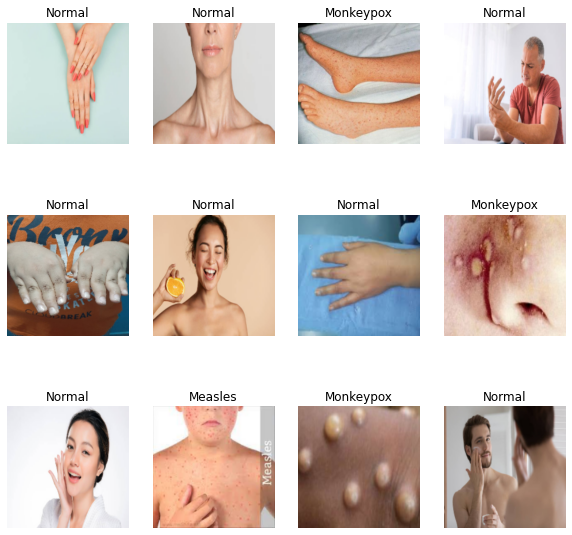

In [59]:
plt.figure(figsize=(10,10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.title(class_names[labels_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [60]:
train_size = 0.8
len(dataset)*train_size

17.6

In [61]:
train_ds = dataset.take(16)
len(train_ds)

16

In [62]:
test_ds = dataset.skip(16)
len(test_ds)

6

In [63]:
val_size = 0.1
len(dataset)*val_size

2.2

In [64]:
#80% ==> Training
#20% ==> Test
    #10% ==> Validation
    #10% ==> Test

In [65]:
val_ds = test_ds.take(2)
len(val_ds)

2

In [66]:
test_ds = test_ds.skip(2)
len(test_ds)

4

In [67]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert(train_split+test_split+val_split)==1
    
    ds_size= len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [68]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [69]:
len(train_ds)

17

In [70]:
len(val_ds)

2

In [71]:
len(test_ds)

3

In [72]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [73]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  ...
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]]

 [[0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  ...
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]]

 [[0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  ...
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]
  [0.84705883 0.8627451  0.85882354]]

 ...

 [[0.8156863  0.8509804  0.84705883]
  [0.8156863  0.8509804  0.84705883]
  [0.8156863  0.8509804  0.84705883]
  ...
  [0.82230395 0.85759807 0.8536765 ]
  [0.8181372  0.8541667  0.8502451 ]
  [0.8117647  0.8509804  0.84705883]]

 [[0.8156863  0.8509804  0.84705883]
  [0.8156863  0.8509804  0.84705883]


In [74]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [75]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [76]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
    
    
    
])

model.build(input_shape = input_shape)

In [77]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 sequential_7 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d_12 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 127, 127, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 62, 62, 64)       0         
 g2D)                                                 

In [78]:
X = train_ds
y= test_ds

In [79]:
model.compile(
   optimizer='adam', 
   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
   metrics=['accuracy']
)

In [80]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/100
17/17 [==============================] - 31s 1s/step - loss: 1.0985 - accuracy: 0.4408 - val_loss: 0.9941 - val_accuracy: 0.4531
Epoch 2/100
17/17 [==============================] - 23s 1s/step - loss: 1.0076 - accuracy: 0.4294 - val_loss: 0.9846 - val_accuracy: 0.4531
Epoch 3/100
17/17 [==============================] - 22s 1s/step - loss: 0.9850 - accuracy: 0.5038 - val_loss: 0.9296 - val_accuracy: 0.4844
Epoch 4/100
17/17 [==============================] - 22s 1s/step - loss: 0.9264 - accuracy: 0.5267 - val_loss: 0.8786 - val_accuracy: 0.7031
Epoch 5/100
17/17 [==============================] - 22s 1s/step - loss: 0.8887 - accuracy: 0.6298 - val_loss: 0.8934 - val_accuracy: 0.7031
Epoch 6/100
17/17 [==============================] - 23s 1s/step - loss: 0.8338 - accuracy: 0.6469 - val_loss: 0.7701 - val_accuracy: 0.6875
Epoch 7/100
17/17 [==============================] - 23s 1s/step - loss: 0.8388 - accuracy: 0.6107 - val_loss: 0.8095 - val_accuracy: 0.6719
Epoch 8/100
1

Epoch 49/100
17/17 [==============================] - 27s 2s/step - loss: 0.3133 - accuracy: 0.8912 - val_loss: 0.9879 - val_accuracy: 0.7500
Epoch 50/100
17/17 [==============================] - 28s 2s/step - loss: 0.3357 - accuracy: 0.8626 - val_loss: 0.5842 - val_accuracy: 0.8281
Epoch 51/100
17/17 [==============================] - 28s 2s/step - loss: 0.3259 - accuracy: 0.8664 - val_loss: 0.5852 - val_accuracy: 0.8750
Epoch 52/100
17/17 [==============================] - 28s 2s/step - loss: 0.2481 - accuracy: 0.9008 - val_loss: 0.6609 - val_accuracy: 0.8594
Epoch 53/100
17/17 [==============================] - 28s 2s/step - loss: 0.2319 - accuracy: 0.9103 - val_loss: 0.7807 - val_accuracy: 0.8438
Epoch 54/100
17/17 [==============================] - 28s 2s/step - loss: 0.3276 - accuracy: 0.8702 - val_loss: 0.8604 - val_accuracy: 0.8125
Epoch 55/100
17/17 [==============================] - 27s 2s/step - loss: 0.2678 - accuracy: 0.9027 - val_loss: 0.8413 - val_accuracy: 0.7656
Epoch 

In [81]:
scores = model.evaluate(test_ds)

3/3 [==============================] - 2s 216ms/step - loss: 0.7598 - accuracy: 0.8854


In [82]:
history.history['accuracy']

[0.4408397078514099,
 0.4293893277645111,
 0.5038167834281921,
 0.5267175436019897,
 0.6297709941864014,
 0.6469465494155884,
 0.6106870174407959,
 0.6870229244232178,
 0.6583969593048096,
 0.6622137427330017,
 0.6908397078514099,
 0.6927480697631836,
 0.7194656729698181,
 0.7194656729698181,
 0.6927480697631836,
 0.6889312863349915,
 0.7347328066825867,
 0.7442747950553894,
 0.7385495901107788,
 0.7633587718009949,
 0.7519084215164185,
 0.7729007601737976,
 0.7900763154029846,
 0.7729007601737976,
 0.7958015203475952,
 0.8034350872039795,
 0.7938931584358215,
 0.7919847369194031,
 0.8015267252922058,
 0.7824427485466003,
 0.8091602921485901,
 0.8148854970932007,
 0.847328245639801,
 0.8206107020378113,
 0.8530534505844116,
 0.8664122223854065,
 0.8492366671562195,
 0.8435114622116089,
 0.8435114622116089,
 0.847328245639801,
 0.8702290058135986,
 0.8702290058135986,
 0.885496199131012,
 0.8874045610427856,
 0.8492366671562195,
 0.885496199131012,
 0.9045801758766174,
 0.87404578924179

In [83]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

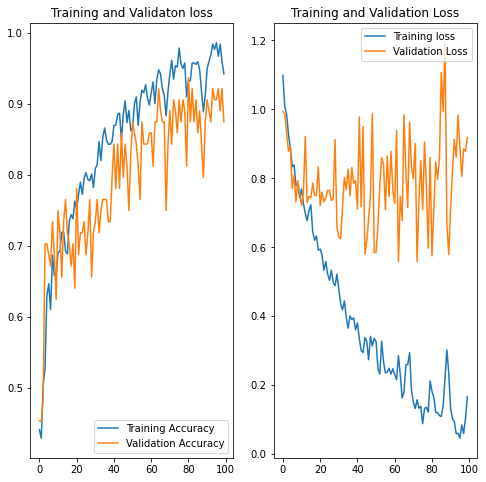

In [84]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validaton loss')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss,label='Training loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


First image to predict
Label: Monkeypox
1/1 [==============================] - 1s 815ms/step
Predicted Label: Monkeypox


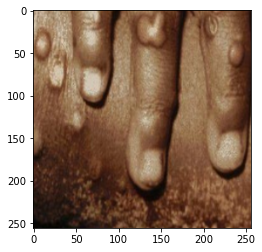

In [85]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype("uint8")
    
    print("First image to predict")
    plt.imshow(first_image)
    print("Label:", class_names[labels_batch[0].numpy()])
    
    batch_prediction = model.predict(images_batch)
    print("Predicted Label:",class_names[np.argmax(batch_prediction[0])])

In [116]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [117]:
!git init

Initialized empty Git repository in C:/Users/DELL/Desktop/skin/.git/


In [118]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Disease/
	disease-ditection/
	disease.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [119]:
!git add .

error: 'disease-ditection/' does not have a commit checked out
fatal: adding files failed


In [121]:
!git commit -m "first commit"

On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Disease/
	disease-ditection/
	disease.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [122]:
!git clone https://github.com/Sakhawat-Saim/disease-ditection.git

fatal: destination path 'disease-ditection' already exists and is not an empty directory.


In [143]:
!git init

Initialized empty Git repository in C:/Users/DELL/Desktop/skin/.git/


In [144]:
!git remote add origin https://github.com/Sakhawat-Saim/disease-ditection.git

In [145]:
!git add .
!git commit -m "Initial commit"

[master (root-commit) 0855b04] Initial commit
 836 files changed, 2446 insertions(+)
 create mode 100644 .ipynb_checkpoints/disease-checkpoint.ipynb
 create mode 100644 Disease/Chickenpox/1.jfif
 create mode 100644 Disease/Chickenpox/10.jfif
 create mode 100644 Disease/Chickenpox/11.jfif
 create mode 100644 Disease/Chickenpox/12.jfif
 create mode 100644 Disease/Chickenpox/13.jfif
 create mode 100644 Disease/Chickenpox/14.jfif
 create mode 100644 Disease/Chickenpox/15.jfif
 create mode 100644 Disease/Chickenpox/16.jfif
 create mode 100644 Disease/Chickenpox/17.jfif
 create mode 100644 Disease/Chickenpox/18.jfif
 create mode 100644 Disease/Chickenpox/19.jfif
 create mode 100644 Disease/Chickenpox/2.jfif
 create mode 100644 Disease/Chickenpox/20.jfif
 create mode 100644 Disease/Chickenpox/21.jfif
 create mode 100644 Disease/Chickenpox/22.jfif
 create mode 100644 Disease/Chickenpox/23.jfif
 create mode 100644 Disease/Chickenpox/24.jfif
 create mode 100644 Disease/Chickenpox/25.jfif
 create

 create mode 100644 Disease/Monkeypox/17.jfif
 create mode 100644 Disease/Monkeypox/18.jfif
 create mode 100644 Disease/Monkeypox/19.jfif
 create mode 100644 Disease/Monkeypox/2.jfif
 create mode 100644 Disease/Monkeypox/20.jfif
 create mode 100644 Disease/Monkeypox/21.jfif
 create mode 100644 Disease/Monkeypox/22.jfif
 create mode 100644 Disease/Monkeypox/23.jfif
 create mode 100644 Disease/Monkeypox/24.jfif
 create mode 100644 Disease/Monkeypox/25.jfif
 create mode 100644 Disease/Monkeypox/26.jfif
 create mode 100644 Disease/Monkeypox/27.jfif
 create mode 100644 Disease/Monkeypox/28.jfif
 create mode 100644 Disease/Monkeypox/29.jfif
 create mode 100644 Disease/Monkeypox/3.jfif
 create mode 100644 Disease/Monkeypox/30.jfif
 create mode 100644 Disease/Monkeypox/31.jfif
 create mode 100644 Disease/Monkeypox/32.jfif
 create mode 100644 Disease/Monkeypox/33.jfif
 create mode 100644 Disease/Monkeypox/34.jfif
 create mode 100644 Disease/Monkeypox/35.jfif
 create mode 100644 Disease/Monkeypo

 create mode 100644 Disease/Monkeypox/monkeypox244.png
 create mode 100644 Disease/Monkeypox/monkeypox245.png
 create mode 100644 Disease/Monkeypox/monkeypox246.png
 create mode 100644 Disease/Monkeypox/monkeypox247.png
 create mode 100644 Disease/Monkeypox/monkeypox248.png
 create mode 100644 Disease/Monkeypox/monkeypox249.png
 create mode 100644 Disease/Monkeypox/monkeypox25.png
 create mode 100644 Disease/Monkeypox/monkeypox250.png
 create mode 100644 Disease/Monkeypox/monkeypox251.png
 create mode 100644 Disease/Monkeypox/monkeypox252.png
 create mode 100644 Disease/Monkeypox/monkeypox253.png
 create mode 100644 Disease/Monkeypox/monkeypox254.png
 create mode 100644 Disease/Monkeypox/monkeypox255.png
 create mode 100644 Disease/Monkeypox/monkeypox256.png
 create mode 100644 Disease/Monkeypox/monkeypox257.png
 create mode 100644 Disease/Monkeypox/monkeypox258.png
 create mode 100644 Disease/Monkeypox/monkeypox259.png
 create mode 100644 Disease/Monkeypox/monkeypox26.png
 create mode

In [146]:
!git branch -M main
!git push -u origin main

remote: error: GH013: Repository rule violations found for refs/heads/main.        
remote: 
remote: - GITHUB PUSH PROTECTION        
remote:   â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”        
remote:     Resolve the following violations before pushing again        
remote: 
remote:     - Push cannot contain secrets        
remote: 
remote:             
remote:      (?) Learn how to resolve a blocked push        
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push        
remote:             
remote:             
remote:       â€”â€” GitHub Personal Access Token â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”â€”        
remote:        locations:        
remote:          - commit: 0855b04638755311b50debfb2dc25c4b040441ee        
remote:            path